# Embedding Layer Analysis
This notebook explores the relationship between the weight matrix of an embedding layer and the backpropagation process in neural networks. We will use Pandas for data manipulation and visualizations to enhance understanding.

## Introduction
In neural networks, the embedding layer is crucial for converting categorical data into a continuous vector space. Understanding how the weights of this layer are updated during backpropagation is essential for grasping the learning process.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

## Simulating an Embedding Layer
Let's create a simple embedding layer with a weight matrix and simulate the forward and backward pass.

In [2]:
# Parameters
vocab_size = 10  # Number of unique words
embedding_dim = 4  # Dimension of the embedding vector

# Initialize the weight matrix randomly
weights = np.random.rand(vocab_size, embedding_dim)
weights_df = pd.DataFrame(weights, columns=[f'Feature {i+1}' for i in range(embedding_dim)])
weights_df.index.name = 'Word Index'
weights_df

,Feature 1,Feature 2,Feature 3,Feature 4
Word Index,,,,
0,0.374540,0.950714,0.731994,0.598658
1,0.156019,0.155995,0.058084,0.866176
2,0.601115,0.708073,0.020584,0.969910
3,0.832443,0.212339,0.181825,0.183405
4,0.304242,0.524756,0.431945,0.291229
5,0.611853,0.139494,0.292145,0.366362
6,0.456070,0.785176,0.199674,0.514234
7,0.592415,0.046450,0.607545,0.170524
8,0.065052,0.948886,0.965632,0.808397


## Forward Pass
In the forward pass, we will retrieve the embedding vectors for a sample input and visualize them.

In [3]:
# Sample input (word indices)
input_indices = [0, 2, 4]

# Retrieve the corresponding embeddings
embeddings = weights[input_indices]
embeddings_df = pd.DataFrame(embeddings, index=input_indices, columns=[f'Feature {i+1}' for i in range(embedding_dim)])
embeddings_df

,Feature 1,Feature 2,Feature 3,Feature 4
0,0.374540,0.950714,0.731994,0.598658
2,0.601115,0.708073,0.020584,0.969910
4,0.304242,0.524756,0.431945,0.291229


## Visualizing the Embeddings
Let's visualize the embeddings in a 2D space using PCA.

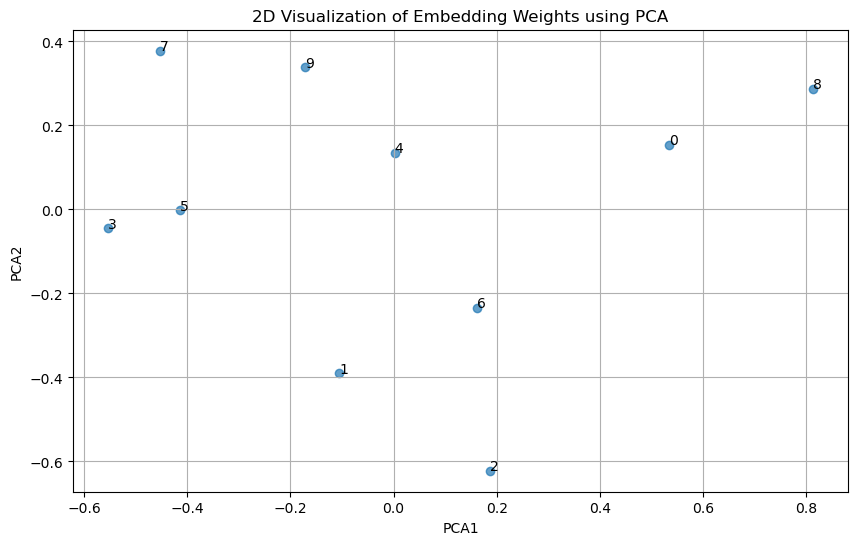

In [4]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(weights)

# Create a DataFrame for visualization
reduced_df = pd.DataFrame(reduced_embeddings, columns=['PCA1', 'PCA2'])
reduced_df['Word Index'] = reduced_df.index

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(reduced_df['PCA1'], reduced_df['PCA2'], alpha=0.7)
for i in range(len(reduced_df)):
    plt.annotate(reduced_df['Word Index'][i], (reduced_df['PCA1'][i], reduced_df['PCA2'][i]))
plt.title('2D Visualization of Embedding Weights using PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.show()

## Backpropagation Simulation
Now, let's simulate a simple backpropagation step to see how the weights are updated.

In [5]:
# Simulated gradients from the loss function
gradients = np.random.rand(vocab_size, embedding_dim) * 0.01  # Small gradients

# Learning rate
learning_rate = 0.1

# Update weights
weights -= learning_rate * gradients
updated_weights_df = pd.DataFrame(weights, columns=[f'Feature {i+1}' for i in range(embedding_dim)])
updated_weights_df.index.name = 'Word Index'
updated_weights_df

,Feature 1,Feature 2,Feature 3,Feature 4
Word Index,,,,
0,0.374418,0.950219,0.731960,0.597749
1,0.155760,0.155332,0.057772,0.865656
2,0.600568,0.707888,0.019615,0.969135
3,0.831503,0.211444,0.181227,0.182483
4,0.304154,0.524560,0.431900,0.290904
5,0.611464,0.139223,0.291316,0.366005
6,0.455789,0.784633,0.199533,0.513432
7,0.592340,0.045464,0.606773,0.170325
8,0.065046,0.948070,0.964925,0.807668


## Conclusion
In this notebook, we explored the embedding layer's weight matrix and its relationship with backpropagation. We visualized the embeddings and demonstrated how they are updated during training.